## Data Understanding and Cleaning Pipeline

### This notebook performs an initial exploration and cleaning of the dataset. It focuses on understanding data structure, identifying missing values, detecting inconsistencies, and preparing the data for further analysis or modeling.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import emoji

In [2]:
# Load your dataset
org_df = pd.read_csv('E://CV//Internship//Coding_Challenge_Omkar_Pawar//data//nlp_data.csv')

In [3]:
df_1 = org_df.copy()

In [4]:
df_1

,id,product,sentiment,text
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...
...,...,...,...,...
75677,4891,GrandTheftAuto(GTA),Irrelevant,⭐️ Toronto is the arts and culture capital of ...
75678,4359,CS-GO,Irrelevant,tHIS IS ACTUALLY A GOOD MOVE TOT BRING MORE VI...
75679,2652,Borderlands,Positive,Today sucked so it’s time to drink wine n play...
75680,8069,Microsoft,Positive,Bought a fraction of Microsoft today. Small wins.


In [6]:
df_1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 75682 entries, 0 to 75681
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   id         75682 non-null  int64 
 1   product    75682 non-null  object
 2   sentiment  75682 non-null  object
 3   text       74996 non-null  object
dtypes: int64(1), object(3)
memory usage: 2.3+ MB


In [5]:
df_1[df_1['id'] == 2401]

,id,product,sentiment,text
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...
5,2401,Borderlands,Positive,im getting into borderlands and i can murder y...


In [8]:
# 1) Per-id consistency summary
per_id = (
    df_1.groupby('id')
        .agg(
            n_rows=('id', 'size'),
            n_sentiments=('sentiment', 'nunique'),
            sentiments=('sentiment', lambda s: tuple(sorted(s.unique()))),
            n_products=('product', 'nunique'),
            products=('product',  lambda s: tuple(sorted(s.unique())))
        )
        .reset_index()
)

# 2) IDs that violate consistency
bad_ids = per_id.query('n_sentiments > 1 or n_products > 1')

print(f"Total unique IDs: {per_id.shape[0]}")
print(f"IDs with inconsistent sentiment and/or product: {bad_ids.shape[0]}")
display(bad_ids.head(10))  # or print(bad_ids.head(10))

Total unique IDs: 12447
IDs with inconsistent sentiment and/or product: 0


,id,n_rows,n_sentiments,sentiments,n_products,products


In [9]:
per_id

,id,n_rows,n_sentiments,sentiments,n_products,products
0,1,6,1,"(Negative,)",1,"(Amazon,)"
1,2,6,1,"(Negative,)",1,"(Amazon,)"
2,3,6,1,"(Neutral,)",1,"(Amazon,)"
3,4,6,1,"(Negative,)",1,"(Amazon,)"
4,5,6,1,"(Irrelevant,)",1,"(Amazon,)"
...,...,...,...,...,...,...
12442,13196,6,1,"(Irrelevant,)",1,"(Xbox(Xseries),)"
12443,13197,7,1,"(Neutral,)",1,"(Xbox(Xseries),)"
12444,13198,6,1,"(Positive,)",1,"(Xbox(Xseries),)"
12445,13199,6,1,"(Irrelevant,)",1,"(Xbox(Xseries),)"


In [10]:
bad_ids

,id,n_rows,n_sentiments,sentiments,n_products,products


- Each ID maps to one product and sentiment but slightly varied texts (possible paraphrases). 
- To prevent data leakage and ensure fair evaluation, I applied group-aware splitting 
so that all samples of the same ID remain in a single data partition.

### Missing data: Sentiment Distribution Analysis

In [12]:
df_2 = df_1.copy()

In [13]:
df_2 = df_1.copy()

# 0) Normalize common "invisible" characters (tabs, NBSP, zero-widths, etc.)
#    - \x00-\x1F  -> ASCII control chars (incl. \t, \n, \r)
#    - \u00A0     -> NBSP
#    - \u1680,\u180E,\u2000-\u200D,\u202F,\u205F,\u3000,\uFEFF -> various Unicode spaces/ZW*
invisibles = r'[\x00-\x1F\u00A0\u1680\u180E\u2000-\u200D\u202F\u205F\u3000\uFEFF]'

# Cleaned view of the text column for missingness detection
text_clean = (
    df_2['text']
    .astype(str)                              # safe for NaNs downstream
    .str.replace(invisibles, ' ', regex=True) # normalize invisibles to spaces
    .str.strip()                              # collapse to detect "empty"
)

# 1) Enhanced missing mask for `text`: NaN OR becomes empty after cleaning
empty_text_mask = df_2['text'].isna() | text_clean.eq('')

# 2) Missing table (counts + pct). Start with raw NaNs for all columns,
#    then overwrite `text` with the enhanced count.
missing = df_2.isna().sum().to_frame('missing')
missing.loc['text', 'missing'] = int(empty_text_mask.sum())

# 3) Percentages (as 0–100%), rounded nicely
missing['pct'] = (missing['missing'] / len(df_2) * 100).round(2)

missing

,missing,pct
id,0,0.00
product,0,0.00
sentiment,0,0.00
text,858,1.13


In [14]:
empty_rows_df = df_2[empty_text_mask]

In [15]:
empty_rows_df

,id,product,sentiment,text
61,2411,Borderlands,Neutral,NaN
553,2496,Borderlands,Neutral,NaN
589,2503,Borderlands,Neutral,NaN
745,2532,Borderlands,Positive,NaN
1105,2595,Borderlands,Positive,NaN
...,...,...,...,...
73973,9073,Nvidia,Positive,NaN
74418,9154,Nvidia,Positive,
74421,9154,Nvidia,Positive,NaN
74422,9154,Nvidia,Positive,NaN


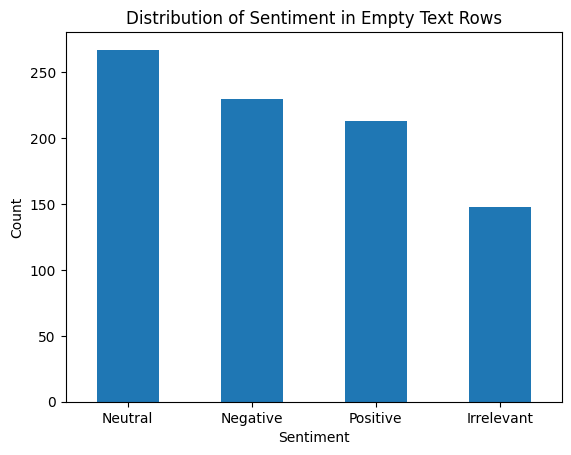

In [16]:
# Distribution by sentiment

empty_rows_df['sentiment'].value_counts().plot(
    kind='bar',
    title='Distribution of Sentiment in Empty Text Rows',
    xlabel='Sentiment',
    ylabel='Count',
    rot=0
)
plt.show()

The visualization shows the sentiment distribution among rows with empty text. Most missing texts are labeled Neutral, followed by Negative and Positive, while Irrelevant has the fewest entries.

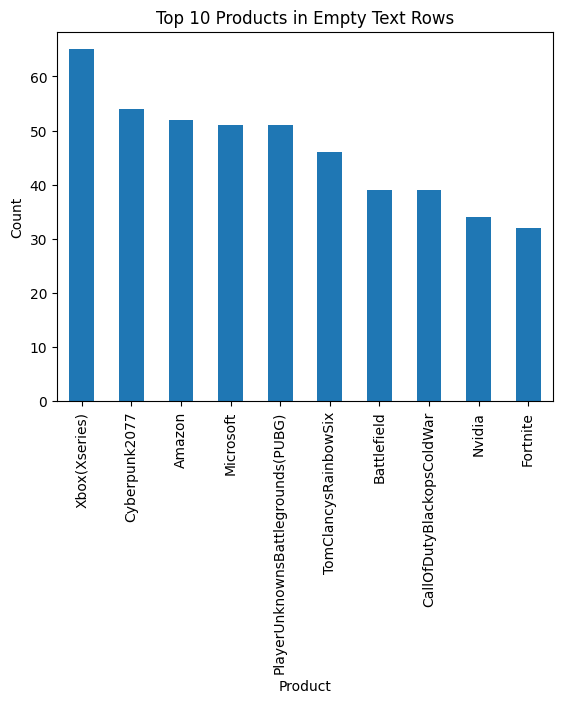

In [17]:
# Distribution by product

empty_rows_df['product'].value_counts().head(10).plot(
    kind='bar',
    title='Top 10 Products in Empty Text Rows',
    xlabel='Product',
    ylabel='Count',
    rot=90
)
plt.show()

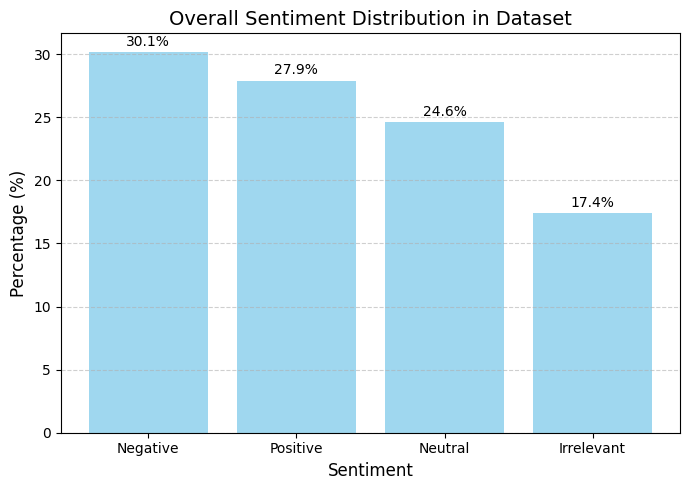

In [19]:
# Compute sentiment distribution (in entire dataset)
sentiment_counts = df_2['sentiment'].value_counts(normalize=True) * 100

# Plot
plt.figure(figsize=(7,5))
plt.bar(sentiment_counts.index, sentiment_counts.values, color='skyblue', alpha=0.8)

# Add labels and formatting
plt.title('Overall Sentiment Distribution in Dataset', fontsize=14)
plt.xlabel('Sentiment', fontsize=12)
plt.ylabel('Percentage (%)', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Add value labels on top of bars
for i, v in enumerate(sentiment_counts.values):
    plt.text(i, v + 0.5, f"{v:.1f}%", ha='center', fontsize=10)

plt.tight_layout()
plt.show()

The visualization shows the overall sentiment distribution in the dataset. Negative and Positive sentiments are most common, while Neutral and Irrelevant appear less frequently. This indicates a slight skew toward emotionally charged sentiments.

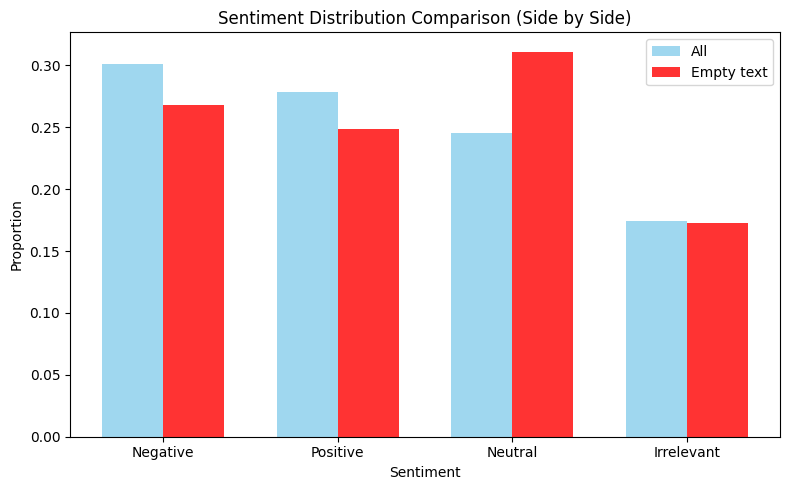

In [20]:
# Get normalized distributions
all_sentiment = df_2['sentiment'].value_counts(normalize=True)
empty_sentiment = empty_rows_df['sentiment'].value_counts(normalize=True)

# Ensure both have same index order
sentiments = all_sentiment.index
empty_sentiment = empty_sentiment.reindex(sentiments, fill_value=0)

# Set positions for bars
x = np.arange(len(sentiments))  # label locations
width = 0.35  # width of the bars

# Create figure
fig, ax = plt.subplots(figsize=(8, 5))

# Plot side-by-side bars
ax.bar(x - width/2, all_sentiment.values, width, label='All', color='skyblue', alpha=0.8)
ax.bar(x + width/2, empty_sentiment.values, width, label='Empty text', color='red', alpha=0.8)

# Labels and title
ax.set_xlabel('Sentiment')
ax.set_ylabel('Proportion')
ax.set_title('Sentiment Distribution Comparison (Side by Side)')
ax.set_xticks(x)
ax.set_xticklabels(sentiments, rotation=0)
ax.legend()

plt.tight_layout()
plt.show()

The proportion of empty-text samples is largely consistent with the overall sentiment distribution, indicating balanced missingness across most classes.
However, the Neutral class shows a noticeably higher fraction of missing data, meaning a larger percentage of Neutral samples will be dropped during cleaning compared to other sentiment classes.

### Missing Data Handling

In [21]:
### Drop rows with empty text col
# Drop empty-text rows
df_clean = df_2[~empty_text_mask].copy()

In [22]:
df_clean

,id,product,sentiment,text
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...
...,...,...,...,...
75677,4891,GrandTheftAuto(GTA),Irrelevant,⭐️ Toronto is the arts and culture capital of ...
75678,4359,CS-GO,Irrelevant,tHIS IS ACTUALLY A GOOD MOVE TOT BRING MORE VI...
75679,2652,Borderlands,Positive,Today sucked so it’s time to drink wine n play...
75680,8069,Microsoft,Positive,Bought a fraction of Microsoft today. Small wins.


In [23]:
## check for duplicates
# Count total duplicate rows (entire-row duplicates)
num_dupes = df_clean.duplicated().sum()
print(f"Total duplicate rows: {num_dupes}")

# Drop exact duplicates
df_clean = df_clean.drop_duplicates().reset_index(drop=True)

print(f"Rows after removing duplicates: {len(df_clean)}")

Total duplicate rows: 2857
Rows after removing duplicates: 71967


In [24]:
# Snaity check
df_clean.duplicated().sum()

np.int64(0)

Duplicate Handling:
- A total of 2,857 full-row duplicates (~3.8% of the dataset) were identified and removed. 
- These entries were identical across all features (id, product, sentiment, and text). 
Removing them helps prevent redundancy and potential bias during model training. 
The overall sentiment distribution remained consistent after their removal.

In [26]:
df_clean['sentiment'].value_counts(normalize=True) * 100

sentiment
Negative      30.213848
Positive      27.526505
Neutral       24.764128
Irrelevant    17.495519
Name: proportion, dtype: float64

### Label inconsistency

In [28]:
#label consistency check
# Group by 'text' and count how many unique sentiments each text has

# --- Step 1: Drop label-inconsistent texts (same text → multiple sentiments) ---

# 1) Find texts that have >1 unique sentiment
sent_per_text = (
    df_clean.groupby('text', dropna=False)['sentiment']
            .nunique()
)
conflicting_texts = sent_per_text[sent_per_text > 1].index

# 2) Report how much we’ll drop
n_conflicting_texts = len(conflicting_texts)
n_rows_conflicting = df_clean['text'].isin(conflicting_texts).sum()
print(f"Conflicting texts: {n_conflicting_texts}")
print(f"Rows to drop (label-inconsistent): {n_rows_conflicting}")

Conflicting texts: 136
Rows to drop (label-inconsistent): 1892


In [29]:
list(conflicting_texts)

[' .  ',
 ' . .  ',
 ' . . store.playstation.com/ ',
 '.',
 '. 7.',
 '. <unk>',
 '. A',
 '. http store.playstation.com/',
 '..',
 '.. store.playstation.com /',
 '...',
 '... store.playstation.com /',
 '....',
 '2',
 '3.',
 '<unk>',
 '<unk>.',
 '@ GhostRecon',
 'A',
 'Always.',
 'At the same time, despite the fact that there are currently some 100 million people living below the poverty line, most of them do not have access to health services and do not have access to health care, while most of them do not have access to health care.',
 "Check out @ gringaminginc's fantastic raffle for real cash prizes! Get the best of Daily Fantasy eSports with Dota2, LOL, CS: GO and more: bit.ly / 34qQXkj",
 'Check out my video!  ',
 'Check out the amazing giveaway from @gringaminginc and enter to win real cash prizes! The best in Daily Fantasy eSports featuring Dota2, LOL, CS:GO and More: bit.ly/34qQXkj',
 'Damn',
 'Damn it.',
 'Damned',
 'Holy shit',
 'How',
 'I',
 "I can't wait for this game.",
 'I

In [30]:
df_1[df_1['text'] == 'and']

,id,product,sentiment,text
1637,2686,Borderlands,Positive,and
4523,1977,CallOfDutyBlackopsColdWar,Negative,and
7385,9269,Overwatch,Irrelevant,and
8075,9386,Overwatch,Positive,and
12599,8565,NBA2K,Negative,and
12773,8595,NBA2K,Negative,and
16229,3177,Dota2,Negative,and
19109,12473,WorldOfCraft,Negative,and
21287,4044,CS-GO,Irrelevant,and
21359,4056,CS-GO,Positive,and


In [27]:
# Mark all conflicting texts
conflicting_set = set(conflicting_texts)

# Split short vs long conflicting texts
short_conflicts = [t for t in conflicting_set if len(t.split()) <= 10]
long_conflicts  = [t for t in conflicting_set if len(t.split()) > 10]

print(f"Short conflicting texts: {len(short_conflicts)}")
print(f"Long conflicting texts (for manual review): {len(long_conflicts)}")

# Drop only the short/meaningless conflicting texts
df_label_clean = df_clean[~df_clean['text'].isin(short_conflicts)].copy()

print(f"Rows before: {len(df_clean)} | after label-cleaning: {len(df_label_clean)} "
      f"({len(df_label_clean)/len(df_clean)*100:.2f}% retained)")


Short conflicting texts: 128
Long conflicting texts (for manual review): 8
Rows before: 71967 | after label-cleaning: 70436 (97.87% retained)


In [28]:
long_conflicts

['_ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _',
 'At the same time, despite the fact that there are currently some 100 million people living below the poverty line, most of them do not have access to health services and do not have access to health care, while most of them do not have access to health care.',
 'Check out the amazing giveaway from @gringaminginc and enter to win real cash prizes! The best in Daily Fantasy eSports featuring Dota2, LOL, CS:GO and More: bit.ly/34qQXkj',
 'The best in Daily FeSports featuring Dota2, LOL, CS: GO and more: bit.ly / 34qQXkj',
 "Check out @ gringaminginc's fantastic raffle for real cash prizes! Get 

In [29]:
# Define junk long texts we want to drop
junk_long_conflicts = ['Italy, Italy, Italy, Italy, Italy, Italy, Italy, Italy, Italy, Italy, Italy, Italy, Italy, Italy, Italy, Italy, Italy, Italy, Italy, Italy, Italy, Italy, Italy, Italy, Italy, Italy, Italy, Italy, Italy, Italy, Italy, Italy, Italy, Italy, Italy, Italy, Italy, Italy, Italy, Italy, Italy, Italy, Italy, Italy, Italy, Italy, Italy, Italy, Italy, Italy, Italy, Italy, Italy, Italy, Italy, Italy, Italy, Italy, Italy, Italy, Italy, Italy, Italy, Italy, Italy, Italy, Italy, Italy, Italy, Italy, Italy, Italy, Italy, Italy, Italy, Italy, Italy, Italy, Italy, Italy, Italy, Italy, Italy, Italy, Italy, Italy, Italy, Italy, Italy, Italy, Italy, Italy, Italy, Italy, Italy, Italy, Italy, Italy, Italy,',
                       '_ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _'
                       ]

# Drop those rows
df_label_clean = df_label_clean[~df_label_clean['text'].isin(junk_long_conflicts)].copy()

print(f"Rows after removing junk long conflicts: {len(df_label_clean)}")

# Extract remaining long meaningful conflicts for manual review
manual_review_texts = [
    t for t in long_conflicts
    if t not in junk_long_conflicts
]

manual_review_examples = df_clean[df_clean['text'].isin(manual_review_texts)]
manual_review_examples

Rows after removing junk long conflicts: 70427


,id,product,sentiment,text
2212,1602,CallOfDutyBlackopsColdWar,Irrelevant,It is not the first time that the EU Commissio...
2213,1602,CallOfDutyBlackopsColdWar,Irrelevant,"At the same time, despite the fact that there ..."
2878,1719,CallOfDutyBlackopsColdWar,Positive,It is not the first time that the EU Commissio...
2879,1719,CallOfDutyBlackopsColdWar,Positive,"At the same time, despite the fact that there ..."
3111,1763,CallOfDutyBlackopsColdWar,Neutral,It is not the first time that the EU Commissio...
...,...,...,...,...
70610,9036,Nvidia,Negative,"At the same time, despite the fact that there ..."
70800,9073,Nvidia,Positive,It is not the first time that the EU Commissio...
70801,9073,Nvidia,Positive,"At the same time, despite the fact that there ..."
71230,9154,Nvidia,Positive,It is not the first time that the EU Commissio...


In [30]:
manual_review_texts

['At the same time, despite the fact that there are currently some 100 million people living below the poverty line, most of them do not have access to health services and do not have access to health care, while most of them do not have access to health care.',
 'Check out the amazing giveaway from @gringaminginc and enter to win real cash prizes! The best in Daily Fantasy eSports featuring Dota2, LOL, CS:GO and More: bit.ly/34qQXkj',
 'The best in Daily FeSports featuring Dota2, LOL, CS: GO and more: bit.ly / 34qQXkj',
 "Check out @ gringaminginc's fantastic raffle for real cash prizes! Get the best of Daily Fantasy eSports with Dota2, LOL, CS: GO and more: bit.ly / 34qQXkj",
 'So it is not surprising that the EU Commission has taken a number of measures in recent years to improve the situation in Ukraine.',
 'It is not the first time that the EU Commission has taken such a step.']

In [31]:
check_1_junk = manual_review_examples[manual_review_examples['text'].isin([manual_review_texts[0]])]
check_1_junk

,id,product,sentiment,text
2213,1602,CallOfDutyBlackopsColdWar,Irrelevant,"At the same time, despite the fact that there ..."
2879,1719,CallOfDutyBlackopsColdWar,Positive,"At the same time, despite the fact that there ..."
3112,1763,CallOfDutyBlackopsColdWar,Neutral,"At the same time, despite the fact that there ..."
3771,1880,CallOfDutyBlackopsColdWar,Negative,"At the same time, despite the fact that there ..."
4044,1929,CallOfDutyBlackopsColdWar,Negative,"At the same time, despite the fact that there ..."
...,...,...,...,...
70107,8945,Nvidia,Positive,"At the same time, despite the fact that there ..."
70388,8993,Nvidia,Neutral,"At the same time, despite the fact that there ..."
70610,9036,Nvidia,Negative,"At the same time, despite the fact that there ..."
70801,9073,Nvidia,Positive,"At the same time, despite the fact that there ..."


In [47]:
# Update sentiment labels
df_label_clean.loc[df_label_clean['text'].isin(manual_review_texts), 'sentiment'] = 'Irrelevant'

# Verify
check_irrelevant_updates = df_label_clean[df_label_clean['text'].isin(manual_review_texts)][['id','product','sentiment','text']]
print(f"Total rows updated to 'Irrelevant': {len(check_irrelevant_updates)}")
check_irrelevant_updates.head(10)

Total rows updated to 'Irrelevant': 352


,id,product,sentiment,text
2212,1602,CallOfDutyBlackopsColdWar,Irrelevant,It is not the first time that the EU Commissio...
2213,1602,CallOfDutyBlackopsColdWar,Irrelevant,"At the same time, despite the fact that there ..."
2878,1719,CallOfDutyBlackopsColdWar,Irrelevant,It is not the first time that the EU Commissio...
2879,1719,CallOfDutyBlackopsColdWar,Irrelevant,"At the same time, despite the fact that there ..."
3111,1763,CallOfDutyBlackopsColdWar,Irrelevant,It is not the first time that the EU Commissio...
3112,1763,CallOfDutyBlackopsColdWar,Irrelevant,"At the same time, despite the fact that there ..."
3442,1821,CallOfDutyBlackopsColdWar,Irrelevant,So it is not surprising that the EU Commission...
3770,1880,CallOfDutyBlackopsColdWar,Irrelevant,It is not the first time that the EU Commissio...
3771,1880,CallOfDutyBlackopsColdWar,Irrelevant,"At the same time, despite the fact that there ..."
4043,1929,CallOfDutyBlackopsColdWar,Irrelevant,It is not the first time that the EU Commissio...


In [48]:
df_label_clean['sentiment'].value_counts(normalize=True) * 100

sentiment
Negative      30.177347
Positive      27.364505
Neutral       24.504806
Irrelevant    17.953342
Name: proportion, dtype: float64

In [49]:
df_label_clean

,id,product,sentiment,text
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...
...,...,...,...,...
71962,7516,LeagueOfLegends,Neutral,♥️ Suikoden 2\r\n1️⃣ Alex Kidd in Miracle Worl...
71963,5708,HomeDepot,Positive,Thank you to Matching funds Home Depot RW paym...
71964,2165,CallOfDuty,Neutral,Late night stream with the boys! Come watch so...
71965,4891,GrandTheftAuto(GTA),Irrelevant,⭐️ Toronto is the arts and culture capital of ...


### Save the cleaned data

In [50]:
#df_label_clean.to_csv('E://CV//Internship//Coding_Challenge_Omkar_Pawar//data//cleaned_sentiment_dataset.csv', index=False)